# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score


# Importing Data

In [3]:
df= pd.read_csv("data.csv")
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,1,Clinton Hill Apartment Single Bedroom ! Pratt ~~,30610258,Santiago,Brooklyn,Clinton Hill,40.69591,-73.96284,Private room,58,2,1,9/23/2018,0.10,1,0
1,2,Andy Phillips,6180052,Andrian,Brooklyn,Fort Greene,40.68769,-73.97490,Private room,99,5,4,9/29/2017,0.17,1,250
2,3,"Stylish, Comfortable, and Affordable in Brooklyn",5957027,Zachary,Brooklyn,Crown Heights,40.67667,-73.91750,Entire home/apt,180,2,126,6/14/2019,3.74,1,74
3,4,15 min train ride to Times Sq and US OPEN,101602599,M,Queens,Woodside,40.74340,-73.90588,Entire home/apt,50,1,95,6/24/2019,5.63,2,0
4,5,Sunny 2 bdrm Park Slope Apt w/ Yard 3min to Su...,106168581,Jason,Brooklyn,South Slope,40.66600,-73.99020,Entire home/apt,210,4,88,7/4/2019,4.41,1,20


# EDA + Data Preprocessing

In [4]:
df= df.drop(['id', 'name', 'host_id', 'host_name', 'last_review', 'number_of_reviews', 'reviews_per_month', 'neighbourhood'], axis=1)

In [5]:
df.head()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
0,Brooklyn,40.69591,-73.96284,Private room,58,2,1,0
1,Brooklyn,40.68769,-73.97490,Private room,99,5,1,250
2,Brooklyn,40.67667,-73.91750,Entire home/apt,180,2,1,74
3,Queens,40.74340,-73.90588,Entire home/apt,50,1,2,0
4,Brooklyn,40.66600,-73.99020,Entire home/apt,210,4,1,20


In [6]:
df.isna().sum()

neighbourhood_group               0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [7]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
# total number of rows and columns
df.shape

(27379, 8)

## Function to check for outliers

In [9]:
def check_outlier(df, col):
    q1= df[col].quantile(0.25)
    q3= df[col].quantile(0.75)
    iqr= q3-q1
    lower_bound= q1 - (1.5 * iqr)
    upper_bound= q3 + (1.5 * iqr)
    return df[ (df[col] < lower_bound) | (df[col] > upper_bound)]

## Checking for outliers

In [10]:
check_outlier(df, 'price')

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
17,Manhattan,40.75403,-73.96714,Entire home/apt,714,28,49,250
35,Manhattan,40.73722,-74.00263,Entire home/apt,1500,3,1,54
42,Manhattan,40.74478,-73.98442,Entire home/apt,349,4,1,255
56,Manhattan,40.76515,-73.98586,Entire home/apt,389,1,1,0
75,Manhattan,40.75000,-73.99637,Entire home/apt,395,3,1,0
...,...,...,...,...,...,...,...,...
27286,Manhattan,40.76955,-73.95988,Entire home/apt,589,6,1,4
27326,Brooklyn,40.65716,-73.97550,Entire home/apt,450,4,2,87
27331,Manhattan,40.71895,-73.99793,Entire home/apt,5250,1,1,0
27355,Manhattan,40.74775,-73.99167,Entire home/apt,999,2,1,0


## Result of outliers

Since the data contains outliers, it would negatively affect the model as outliers are data values which are significantly different from the average values, therefore, they can skew the result quite a bit

In [11]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

## Removing Outliers

In [12]:
def remove_outlier(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)  
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df = remove_outlier(df, 'price')
df.shape

(25720, 8)

## Label Encoding

In [13]:
l= LabelEncoder()
df['neighbourhood_group'] = l.fit_transform(df['neighbourhood_group'])
df['room_type'] = l.fit_transform(df['room_type'])

df.head(5)

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
0,1,40.69591,-73.96284,1,58,2,1,0
1,1,40.68769,-73.97490,1,99,5,1,250
2,1,40.67667,-73.91750,0,180,2,1,74
3,3,40.74340,-73.90588,0,50,1,2,0
4,1,40.66600,-73.99020,0,210,4,1,20


# Splitting data into Test and Train Set

In [14]:
X= df.drop(columns= 'price', axis= 1)
y= df['price']

In [15]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

# Scaling of data

In [16]:
s= StandardScaler()
X_train_scaled= s.fit_transform(X_train)
X_test_scaled= s.transform(X_test)

## Crossvalidating the most appropriate model for the dataset

In [17]:
def kfold(estimator, X, y):
    scores = cross_val_score(estimator, X, y, cv=5, scoring='r2')
    print(f"{estimator.__class__.__name__}: {scores.mean():.4f}")

In [18]:
kfold(LinearRegression(), X_train_scaled, y_train)

LinearRegression: 0.4456


In [19]:
kfold(RandomForestRegressor(), X_train_scaled, y_train)

RandomForestRegressor: 0.5454


# Model Training

In [20]:
model= RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [21]:
predictions= model.predict(X_test_scaled)
print("R2: ", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2:  0.5620286604290502
MAE: 32.73893273716952


## Tuning the model

In [22]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), params, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best R2:", grid.best_score_)

Best params: {'max_depth': 10, 'n_estimators': 300}
Best R2: 0.5650075137030436


### best parameters: max depth- 10, n estimators- 300

In [31]:
best_model= grid.best_estimator_
predictions= best_model.predict(X_test_scaled)

In [32]:
pd.DataFrame({'Actual': y_test.values, 'Predicted': predictions}).to_csv('Predictions.csv', index=False)

# Actual vs Predicted values

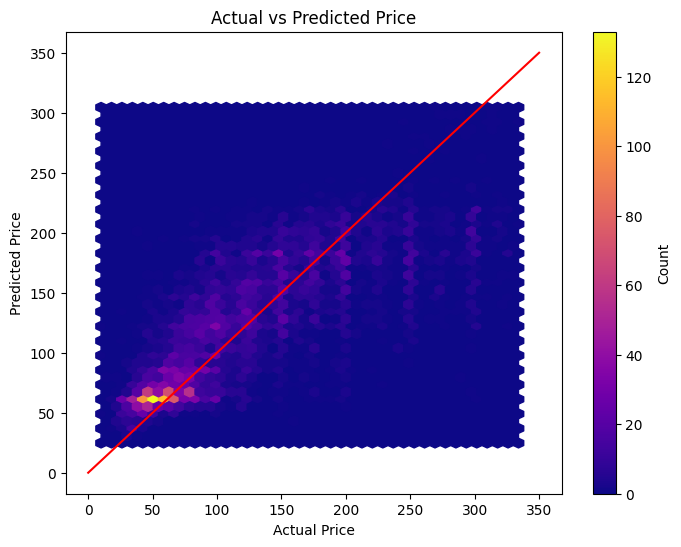

In [33]:
plt.figure(figsize=(8,6))
plt.hexbin(y_test, predictions, gridsize=40, cmap='plasma')
plt.colorbar(label='Count')
plt.plot([0, 350], [0, 350], color='red', linewidth=1.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

#### Model is good at predicting average-priced Airbnbs but gets less accurate as prices get higher

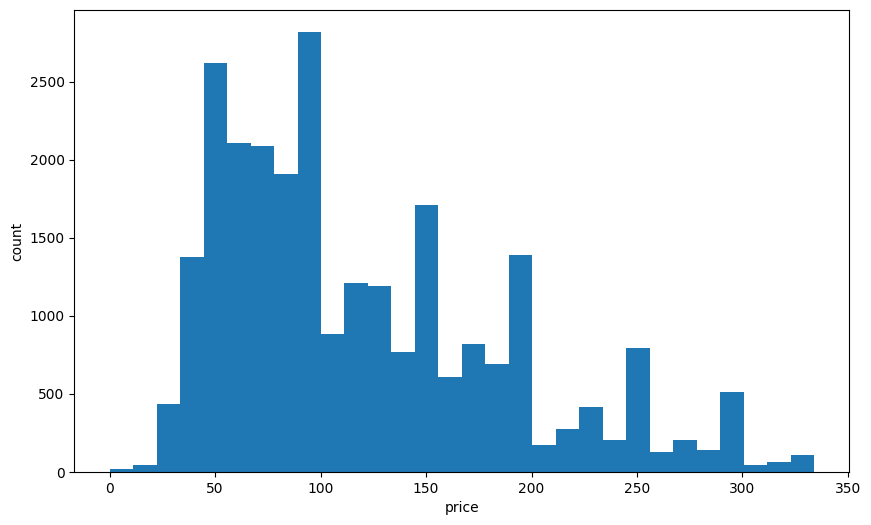

In [34]:
# plot the distribution of price
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30)
plt.xlabel('price')
plt.ylabel('count')
plt.show()

<Axes: xlabel='minimum_nights', ylabel='price'>

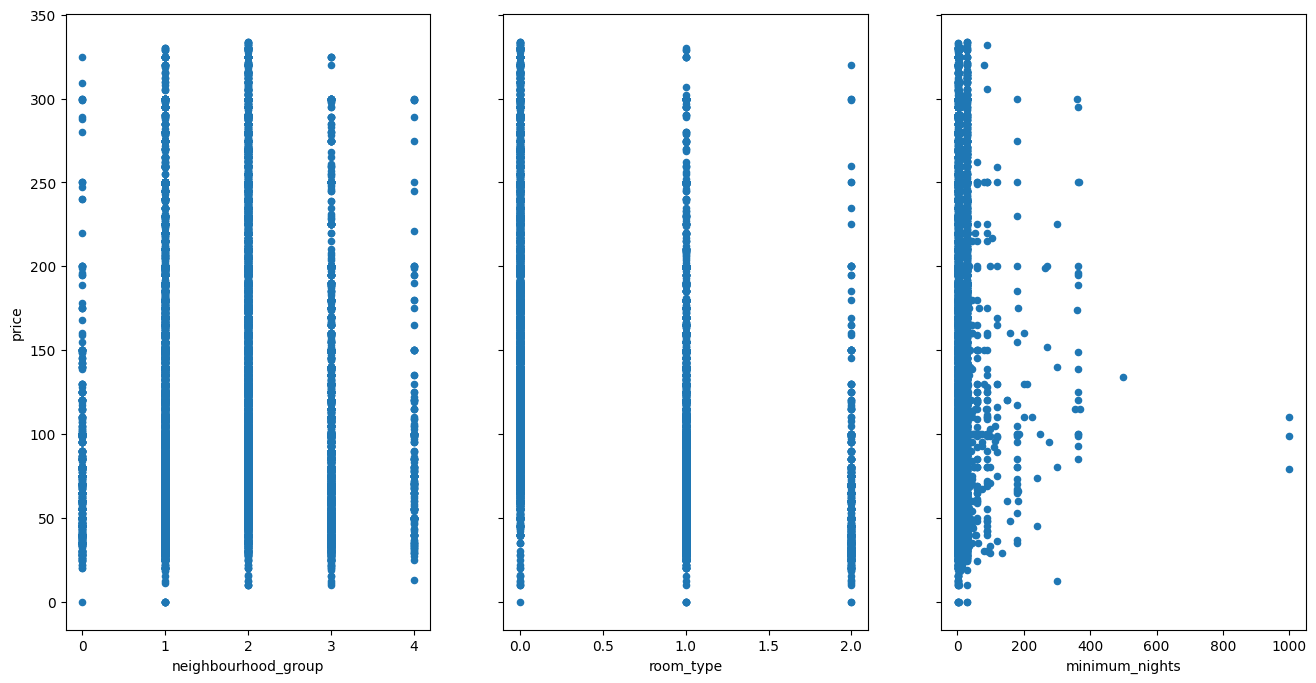

In [35]:
# visualize the relationship between the features and the response using scatterplots
fig, axs = plt.subplots(1, 3, sharey=True)
df.plot(kind='scatter', x='neighbourhood_group', y='price', ax=axs[0], figsize=(16, 8))
df.plot(kind='scatter', x='room_type', y='price', ax=axs[1])
df.plot(kind='scatter', x='minimum_nights', y='price', ax=axs[2])
 

In [36]:
# final description of the dataset
df.describe()

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,calculated_host_listings_count,availability_365
count,25720.000000,25720.000000,25720.000000,25720.000000,25720.000000,25720.000000,25720.000000,25720.000000
mean,1.668118,40.728327,-73.950641,0.526983,119.896384,6.984409,6.687481,109.989969
std,0.746886,0.055444,0.046570,0.545787,68.189097,20.114139,31.021712,130.722864
min,0.000000,40.506410,-74.242850,0.000000,0.000000,1.000000,1.000000,0.000000
25%,1.000000,40.689110,-73.981960,0.000000,65.000000,1.000000,1.000000,0.000000
50%,2.000000,40.721700,-73.954390,1.000000,100.000000,2.000000,1.000000,40.000000
75%,2.000000,40.763272,-73.933797,1.000000,160.000000,5.000000,2.000000,219.000000
max,4.000000,40.913060,-73.717950,2.000000,334.000000,999.000000,327.000000,365.000000
